In [1]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.151 🚀 Python-3.12.3 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 2060, 5740MiB)
Setup complete ✅ (12 CPUs, 15.4 GB RAM, 419.6/467.3 GB disk)


In [2]:
import torch

def check_cuda_availability():
    if torch.cuda.is_available():
        print("CUDA is available")
        device = torch.device("cuda")
    else:
        print("CUDA is NOT available")
        device = torch.device("cpu")

    return device

In [3]:
import platform

if platform.system() == "Darwin":
    print("Your system is  Linux")
    device = check_cuda_availability()
else:
    print("Your system is ", platform.system())
    device = check_cuda_availability()

print("Using device: ", device)

Your system is  Linux
CUDA is available
Using device:  cuda


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random

#### 데이터셋

In [5]:
class SequentialBehaviorDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.FloatTensor(sequences)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

### LSTM 모델

In [6]:
class BehaviorLSTM(nn.Module):
    def __init__(self, input_size=113, hidden_size=256, num_layers=2, num_classes=4, dropout=0.3):
        super(BehaviorLSTM, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc_layers = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes)
        )
    
    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]  # 마지막 시퀀스의 출력만 사용
        return self.fc_layers(last_output)


#### 데이터 로딩

In [7]:
def load_sequential_data(base_path, sequence_length=30):
    """시퀀스 기반 데이터 로드 (병렬 처리)"""
    all_sequences = []
    all_labels = []
    
    classes = ['normal', 'theft', 'broken', 'abandon']
    
    for class_idx, class_name in enumerate(classes):
        print(f"\n📂 {class_name} 클래스 로딩 중...")
        
        # features 디렉토리 찾기
        features_path = os.path.join(base_path, class_name, 'train', 'features')
        if not os.path.exists(features_path):
            print(f"   ⚠️ {features_path} 경로를 찾을 수 없습니다.")
            continue
            
        # 모든 특징 파일 로드
        feature_files = sorted([f for f in os.listdir(features_path) if f.endswith('.txt')])
        print(f"   📄 특징 파일: {len(feature_files)}개")
        
        # 클래스별 시퀀스 카운트를 위한 변수
        initial_sequence_count = len(all_sequences)
        
        # 메모리에 한 번에 로드
        features_data = []
        for file_name in tqdm(feature_files, desc="파일 로딩"):
            file_path = os.path.join(features_path, file_name)
            with open(file_path, 'r') as f:
                values = list(map(float, f.readline().strip().split()))
                features_data.append(values[1:])  # 첫 번째 값은 라벨
        
        # NumPy 배열로 변환하여 빠른 처리
        features_data = np.array(features_data)
        
        # 시퀀스 생성 (벡터화된 연산)
        for i in range(len(features_data) - sequence_length + 1):
            sequence = features_data[i:i + sequence_length]
            all_sequences.append(sequence)
            all_labels.append(class_idx)
        
        # 이 클래스에서 생성된 시퀀스 수 계산
        sequences_generated = len(all_sequences) - initial_sequence_count
        print(f"   ✅ 생성된 시퀀스: {sequences_generated}개")
    
    print(f"\n📊 전체 로딩 결과:")
    print(f"   총 시퀀스: {len(all_sequences)}개")
    print(f"   라벨 분포: {np.bincount(all_labels)}")
    
    # 메모리 효율을 위해 float32로 변환
    return np.array(all_sequences, dtype=np.float32), np.array(all_labels)

In [8]:
def train_model(model, train_loader, val_loader, y_train, num_epochs=100):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=5
)
    
    best_val_acc = 0.0
    patience = 10
    patience_counter = 0
    
    for epoch in range(num_epochs):
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for sequences, labels in train_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for sequences, labels in val_loader:
                sequences, labels = sequences.to(device), labels.to(device)
                outputs = model(sequences)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total
        
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train Loss: {train_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss/len(val_loader):.4f}, Val Acc: {val_acc:.2f}%')
        
        # 모델 저장
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_sequential_model.pt')
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"조기 종료: {patience} epoch 동안 개선 없음")
            break
            
        scheduler.step(val_loss)

In [9]:
if __name__ == "__main__":
    base_path = "../../data/frames"
    sequence_length = 30  # 1초(30fps) 단위로 행동 판단
    
    # 데이터 로드
    sequences, labels = load_sequential_data(base_path, sequence_length)
    
    # 데이터 분할
    X_train, X_test, y_train, y_test = train_test_split(sequences, labels, test_size=0.2)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2)
    
    # 데이터셋 생성
    train_dataset = SequentialBehaviorDataset(X_train, y_train)
    val_dataset = SequentialBehaviorDataset(X_val, y_val)
    test_dataset = SequentialBehaviorDataset(X_test, y_test)
    
    # 클래스 가중치 계산
    class_counts = np.bincount(y_train)
    total_samples = len(y_train)
    class_weights = torch.FloatTensor(total_samples / (len(class_counts) * class_counts))

    # 가중치 기반 샘플링
    train_weights = [class_weights[label] for label in y_train]
    sampler = torch.utils.data.WeightedRandomSampler(
        weights=train_weights,
        num_samples=len(train_weights),
        replacement=True
    )

    # DataLoader에 sampler 적용
    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        sampler=sampler,  # 기존의 shuffle=True 대신 사용
        num_workers=2,
        pin_memory=True
    )
    val_loader = DataLoader(val_dataset, batch_size=32)
    test_loader = DataLoader(test_dataset, batch_size=32)
    
    # 모델 학습
    model = BehaviorLSTM().to(device)
    train_model(model, train_loader, val_loader, y_train)


📂 normal 클래스 로딩 중...
   📄 특징 파일: 72821개


파일 로딩: 100%|██████████| 72821/72821 [00:14<00:00, 4870.00it/s]


   ✅ 생성된 시퀀스: 72792개

📂 theft 클래스 로딩 중...
   📄 특징 파일: 43357개


파일 로딩: 100%|██████████| 43357/43357 [00:02<00:00, 17790.56it/s]


   ✅ 생성된 시퀀스: 43328개

📂 broken 클래스 로딩 중...
   📄 특징 파일: 46951개


파일 로딩: 100%|██████████| 46951/46951 [00:02<00:00, 16709.30it/s]


   ✅ 생성된 시퀀스: 46922개

📂 abandon 클래스 로딩 중...
   📄 특징 파일: 15185개


파일 로딩: 100%|██████████| 15185/15185 [00:00<00:00, 16224.79it/s]


   ✅ 생성된 시퀀스: 15156개

📊 전체 로딩 결과:
   총 시퀀스: 178198개
   라벨 분포: [72792 43328 46922 15156]
Epoch [1/100]
Train Loss: 0.6105, Train Acc: 74.36%
Val Loss: 0.3842, Val Acc: 84.27%
Epoch [2/100]
Train Loss: 0.3429, Train Acc: 86.18%
Val Loss: 0.2756, Val Acc: 88.46%
Epoch [3/100]
Train Loss: 0.2330, Train Acc: 90.98%
Val Loss: 0.1752, Val Acc: 92.76%
Epoch [4/100]
Train Loss: 0.1751, Train Acc: 93.35%
Val Loss: 0.1838, Val Acc: 93.04%
Epoch [5/100]
Train Loss: 0.1451, Train Acc: 94.54%
Val Loss: 0.1363, Val Acc: 94.82%
Epoch [6/100]
Train Loss: 0.1239, Train Acc: 95.49%
Val Loss: 0.1258, Val Acc: 95.50%
Epoch [7/100]
Train Loss: 0.1125, Train Acc: 95.89%
Val Loss: 0.0997, Val Acc: 96.36%
Epoch [8/100]
Train Loss: 0.1022, Train Acc: 96.39%
Val Loss: 0.0665, Val Acc: 97.66%
Epoch [9/100]
Train Loss: 0.0934, Train Acc: 96.65%
Val Loss: 0.0681, Val Acc: 97.56%
Epoch [10/100]
Train Loss: 0.0890, Train Acc: 96.90%
Val Loss: 0.0873, Val Acc: 96.78%
Epoch [11/100]
Train Loss: 0.0854, Train Acc: 97.02

#### 

🧪 모델 성능 평가 시작...


평가 진행 중:   0%|          | 0/891 [00:00<?, ?it/s]

평가 진행 중: 100%|██████████| 891/891 [00:06<00:00, 140.39it/s]



📊 분류 리포트 (Classification Report):
              precision    recall  f1-score   support

      Normal     0.9997    0.9999    0.9998     11612
       Theft     0.9971    0.9900    0.9936      7027
      Broken     0.9907    0.9969    0.9938      7480
     Abandon     0.9996    1.0000    0.9998      2393

    accuracy                         0.9967     28512
   macro avg     0.9968    0.9967    0.9967     28512
weighted avg     0.9967    0.9967    0.9967     28512



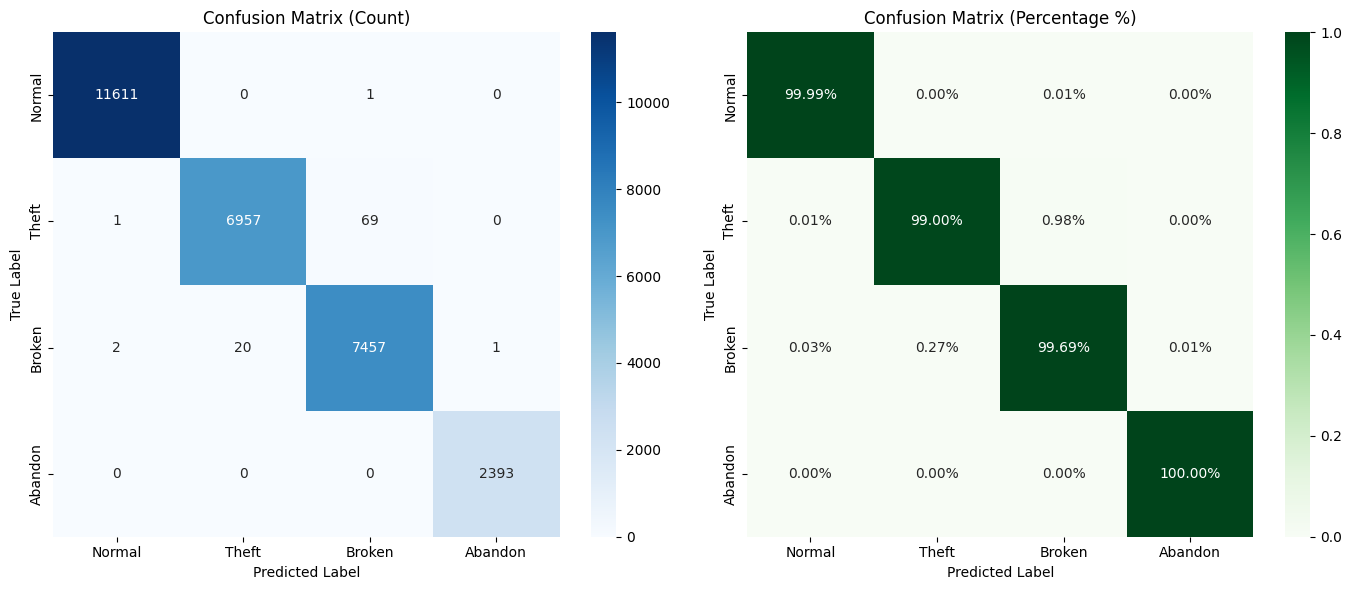

In [12]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- 중요 ---
# 이전에 정의된 BehaviorLSTM 모델 클래스가 이 코드 셀보다 먼저 실행되어 있어야 합니다.
# class BehaviorLSTM(nn.Module):
#     ... (모델 정의)

def evaluate_model(model, data_loader, device, class_names):
    """모델 성능 평가 및 결과 시각화"""
    print("🧪 모델 성능 평가 시작...")
    
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for sequences, labels in tqdm(data_loader, desc="평가 진행 중"):
            sequences = sequences.to(device)
            labels = labels.to(device)
            
            outputs = model(sequences)
            _, predicted = torch.max(outputs.data, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            
    print("\n📊 분류 리포트 (Classification Report):")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # 혼동 행렬 (Confusion Matrix)
    cm = confusion_matrix(y_true, y_pred)
    
    # 혼동 행렬을 퍼센트로 변환
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(14, 6))
    
    # 1. 혼동 행렬 (개수)
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Count)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # 2. 혼동 행렬 (퍼센트)
    plt.subplot(1, 2, 2)
    sns.heatmap(cm_percent, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Percentage %)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.show()

# --- 실행 준비 ---
# 1. 기기 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. 모델 로드 (노트북에 BehaviorLSTM 클래스가 정의되어 있어야 합니다)
model = BehaviorLSTM().to(device) 
model.load_state_dict(torch.load('best_sequential_model.pt')) # 학습 때 저장한 모델 경로

# 3. 데이터 로더 준비
# 학습 과정에서 사용한 val_loader를 그대로 사용합니다.
# 만약 val_loader가 없다면 데이터 로드 및 전처리 코드를 다시 실행해주세요.
# _, val_loader = create_data_loaders(X_train, X_val, y_train, y_val, batch_size=32)

# 4. 클래스 이름 정의
class_names = ['Normal', 'Theft', 'Broken', 'Abandon'] # 라벨 순서와 동일해야 합니다.

# 5. 평가 함수 실행
# val_loader는 학습 시 생성된 검증 데이터 로더입니다.
evaluate_model(model, val_loader, device, class_names)

In [4]:
import torch
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. (예시) 테스트 데이터 준비
# 실제로는 본인 데이터셋/모델에 맞게 수정!
# -------------------------------
# 예시: 1000개 샘플, 113차원 입력, 4개 클래스
num_samples = 1000
num_features = 113
num_classes = 4

# 임의의 데이터 (실제 데이터로 교체!)
X_test = np.random.randn(num_samples, num_features).astype(np.float32)
y_test = np.random.randint(0, num_classes, size=num_samples)

# TensorDataset & DataLoader
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# -------------------------------
# 2. 모델 클래스 정의 (학습 때와 동일하게!)
# -------------------------------
class BehaviorLSTM(torch.nn.Module):
    def __init__(self, input_size=113, hidden_sizes=[256, 128, 64], num_classes=4, dropout=0.3):
        super().__init__()
        layers = []
        current_size = input_size
        for hidden_size in hidden_sizes:
            layers.extend([
                torch.nn.Linear(current_size, hidden_size),
                torch.nn.BatchNorm1d(hidden_size),
                torch.nn.ReLU(),
                torch.nn.Dropout(dropout)
            ])
            current_size = hidden_size
        layers.append(torch.nn.Linear(current_size, num_classes))
        self.network = torch.nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

# -------------------------------
# 3. 저장된 모델 가중치 불러오기
# -------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BehaviorLSTM().to(device)

# 저장된 모델 경로 (본인 파일명으로 수정!)
MODEL_PATH = './best_sequential_model.pt'  # 예시

# state_dict만 저장된 경우
checkpoint = torch.load(MODEL_PATH, map_location=device)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
model.eval()

# -------------------------------
# 4. 평가 (실제/예측 라벨 수집)
# -------------------------------
y_true = []
y_pred = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        outputs = model(X)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# -------------------------------
# 5. 평가 지표 및 혼동행렬 출력
# -------------------------------
class_names = ['Normal', 'Theft', 'Broken', 'Abandon']

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print(f"Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")
print(f"Precision: {precision_score(y_true, y_pred, average='macro') * 100:.2f}%")
print(f"Recall: {recall_score(y_true, y_pred, average='macro') * 100:.2f}%")
print(f"F1 Score: {f1_score(y_true, y_pred, average='macro') * 100:.2f}%")

# -------------------------------
# 6. 혼동행렬 시각화 (선택)
# -------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

RuntimeError: Error(s) in loading state_dict for BehaviorLSTM:
	Missing key(s) in state_dict: "network.0.weight", "network.0.bias", "network.1.weight", "network.1.bias", "network.1.running_mean", "network.1.running_var", "network.4.weight", "network.4.bias", "network.5.weight", "network.5.bias", "network.5.running_mean", "network.5.running_var", "network.8.weight", "network.8.bias", "network.9.weight", "network.9.bias", "network.9.running_mean", "network.9.running_var", "network.12.weight", "network.12.bias". 
	Unexpected key(s) in state_dict: "lstm.weight_ih_l0", "lstm.weight_hh_l0", "lstm.bias_ih_l0", "lstm.bias_hh_l0", "lstm.weight_ih_l1", "lstm.weight_hh_l1", "lstm.bias_ih_l1", "lstm.bias_hh_l1", "fc_layers.0.weight", "fc_layers.0.bias", "fc_layers.1.weight", "fc_layers.1.bias", "fc_layers.1.running_mean", "fc_layers.1.running_var", "fc_layers.1.num_batches_tracked", "fc_layers.4.weight", "fc_layers.4.bias". 